### Dispersion Relation

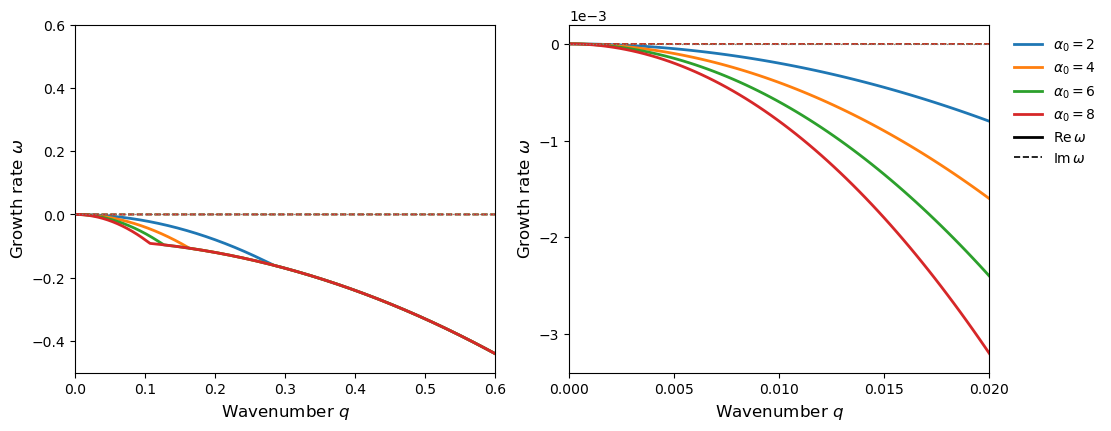

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

phi0 = 0.8
D_c = 1.0
k = 0.1

M0_list = [2, 4, 6, 8]

# larger eigenvalue
def omega_plus(q, M0):
    M = M0 * q**2
    D = D_c * q**2 + k * phi0

    # Linear chemotactic feedback cancels in this limit
    disc = (M - D)**2
    return 0.5 * ( -(M + D) + np.sqrt(disc.astype(complex)))

# plotting settings
q_vals = np.linspace(0, 0.6, 2000)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"][:4]

fig, axes = plt.subplots(1, 2,figsize=(11, 4.2), constrained_layout=True)

for M0, color in zip(M0_list, colors):
    omega = omega_plus(q_vals, M0)

    for ax in axes:
        ax.plot(q_vals, omega.real, color=color, lw=2)
        ax.plot(q_vals, omega.imag,color=color, lw=1.2, ls="--")

for ax in axes:
    ax.axhline(0, color="grey", lw=0.9, ls=":", zorder=3)
    ax.set_xlabel(r"Wavenumber $q$", fontsize=12)
    ax.set_ylabel(r"Growth rate $\omega$", fontsize=12)
    ax.tick_params(axis="both", labelsize=10)

# (a) original range ----------
axes[0].set_xlim(0, 0.6)
axes[0].set_ylim(-0.5, 0.6)


# (b) enlarged near-zero region ----------
axes[1].set_xlim(0, 0.02)
axes[1].set_ylim(-0.0034, 0.0002)
axes[1].set_xticks(np.linspace(0, 0.02, 5))
axes[1].set_yticks([-0.003, -0.002, -0.001, 0])
axes[1].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))


parameter_handles = [Line2D([0], [0], color=color, lw=2,
        label=rf"$\alpha_0={M0}$")
                     for M0, color in zip(M0_list, colors)]

style_handles = [Line2D([0], [0], color="black", lw=2,
                        label=r"$\mathrm{Re}\,\omega$"),
                 Line2D([0], [0], color="black", lw=1.2, ls="--",
                        label=r"$\mathrm{Im}\,\omega$")]

axes[1].legend(handles=parameter_handles + style_handles,bbox_to_anchor=(1.03, 1),
               loc="upper left",fontsize=10,frameon=False)


plt.show()

### Simulation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Grid and Time Parameters 
Nx, Ny = 100, 100
dx, dy = 1.0, 1.0
dt = 1e-3
T  = 1000001

# 2. Model Parameters (Autocrine KS) 
phi0    = 0.8         # mean density
D_phi   = 1.0         # cell diffusion (random motility)
chi0    = 0.5         # chemotactic sensitivity
D_c     = 1.0         # chemical diffusion
k       = 0.1         # uptake rate (autocrine: -k * phi * c)
S       = 0.1         # secretion/supply rate (autocrine: +S * phi)

# 3. Initial Conditions
phi = phi0 + 0.02 * (np.random.rand(Nx, Ny) - 0.5)
c   = 0.02 * (np.random.rand(Nx, Ny) - 0.5)

# 4. Finite Difference Operators (Periodic)
def laplacian(field, dx):
    return (
        np.roll(field, -1, axis=0) + np.roll(field, 1, axis=0) +
        np.roll(field, -1, axis=1) + np.roll(field, 1, axis=1) -
        4.0 * field
    ) / (dx**2)

def gradient_x(field, dx):
    return (np.roll(field, -1, axis=0) - np.roll(field, 1, axis=0)) / (2.0 * dx)

def gradient_y(field, dx):
    return (np.roll(field, -1, axis=1) - np.roll(field, 1, axis=1)) / (2.0 * dx)

# 5. Main Time-Stepping Loop (Explicit Euler)
for t in range(T):

    # 5.1 Gradients
    grad_phi_x = gradient_x(phi, dx)
    grad_phi_y = gradient_y(phi, dx)
    grad_c_x   = gradient_x(c, dx)
    grad_c_y   = gradient_y(c, dx)

    # 5.2 Flux for phi: J = -D_phi ∇phi + chi * phi ∇c
    # PDE: ∂t phi = -∇·J  =>  ∂t phi = ∇·(D_phi ∇phi - chi phi ∇c)
    flux_diff_x = -D_phi * grad_phi_x
    flux_diff_y = -D_phi * grad_phi_y
    flux_chem_x =  chi0 * phi * grad_c_x
    flux_chem_y =  chi0 * phi * grad_c_y

    Jx = flux_diff_x + flux_chem_x
    Jy = flux_diff_y + flux_chem_y

    # 5.3 Divergence of J
    divJ = gradient_x(Jx, dx) + gradient_y(Jy, dx)

    # 5.4 Update phi: ∂t phi = -div(J)
    phi_new = phi - dt * divJ

    # 5.5 Update c (autocrine): ∂t c = D_c ∇^2 c + S phi - k phi c
    lap_c = laplacian(c, dx)
    c_new = c + dt * (D_c * lap_c + S * phi - k * phi * c)

    # 5.6 Synchronize
    phi = phi_new
    c   = c_new

    # 5.7 Bounds (optional but keeps numerics sane)
    phi = np.clip(phi, 0.0, 1.0)
    c   = np.clip(c, 0.0, None)

    # 5.8 Visualization
    if t % 100000 == 0:
        print(f"Time step: {t}, t = {t * dt:.3f}")
        plt.figure(figsize=(12, 5))

        ax1 = plt.subplot(1, 2, 1)
        ax1.set_title(f"phi at t = {t * dt:.3f}")
        im1 = ax1.imshow(phi, origin='lower', cmap='viridis', extent=[0, Nx, 0, Ny])
        plt.colorbar(im1, ax=ax1, label="Density (phi)")

        ax2 = plt.subplot(1, 2, 2)
        ax2.set_title(f"c at t = {t * dt:.3f}")
        im2 = ax2.imshow(c, origin='lower', cmap='inferno', extent=[0, Nx, 0, Ny])
        plt.colorbar(im2, ax=ax2, label="Chemoattractant (c)")

        plt.tight_layout()
        plt.show()  
